# Benchmark Visualization Story

Visualize benchmark results from CSV file in `results/`.


## 1. Imports and Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

WORK_ROOT = Path.cwd().resolve()
if not (WORK_ROOT / "results").exists():
    WORK_ROOT = WORK_ROOT.parent
RESULTS_DIR = WORK_ROOT / "results"


In [2]:
paths = {
    "parquet": RESULTS_DIR / "format" / "trajectory_parquet_format_benchmark.csv",
    "orc": RESULTS_DIR / "format" / "trajectory_orc_format_benchmark.csv",
    "avro": RESULTS_DIR / "format" / "trajectory_avro_format_benchmark.csv",
    "partition": RESULTS_DIR / "partition" / "trajectory_partition_benchmark.csv",
    "join_skew": RESULTS_DIR / "join_skew" / "trajectory_join_skew_benchmark.csv",
    "bucketing_raw": RESULTS_DIR / "bucketing" / "trajectory_bucket_layout_raw_benchmark.csv",
    "bucketing_bucketed": RESULTS_DIR / "bucketing" / "trajectory_bucket_layout_bucketed_benchmark.csv",
}

missing_paths = [name for name, path in paths.items() if not path.exists()]
if missing_paths:
    print("Missing benchmark files:", ", ".join(missing_paths))
else:
    print("All benchmark files detected.")

dfs = {name: pd.read_csv(path) for name, path in paths.items() if path.exists()}
print("Loaded benchmark groups:", ", ".join(sorted(dfs)))


All benchmark files detected.
Loaded benchmark groups: avro, bucketing_bucketed, bucketing_raw, join_skew, orc, parquet, partition


In [3]:
def median_table(df):
    return (
        df.groupby(["query_id", "query_name"], as_index=False)["runtime_sec"]
        .median()
        .rename(columns={"runtime_sec": "median_runtime_sec"})
    )


## 2. Compare storage formats

,query_id,query_name,median_runtime_sec,storage_format
0,Q01,trajectory_projection_scan,0.374301,parquet
1,Q03,vendor_origin_zone_aggregation,0.370770,parquet
2,Q06,route_ranking_window,0.654250,parquet
3,Q07,origin_destination_volume,0.372209,parquet
4,Q01,trajectory_projection_scan,0.388289,orc
5,Q03,vendor_origin_zone_aggregation,0.334731,orc
6,Q06,route_ranking_window,0.741587,orc
7,Q07,origin_destination_volume,0.304160,orc
8,Q01,trajectory_projection_scan,1.349705,avro
9,Q03,vendor_origin_zone_aggregation,1.315384,avro


storage_format,avro,orc,parquet
query_id,,,
Q01,1.349705,0.388289,0.374301
Q03,1.315384,0.334731,0.370770
Q06,1.593166,0.741587,0.654250
Q07,1.256636,0.304160,0.372209


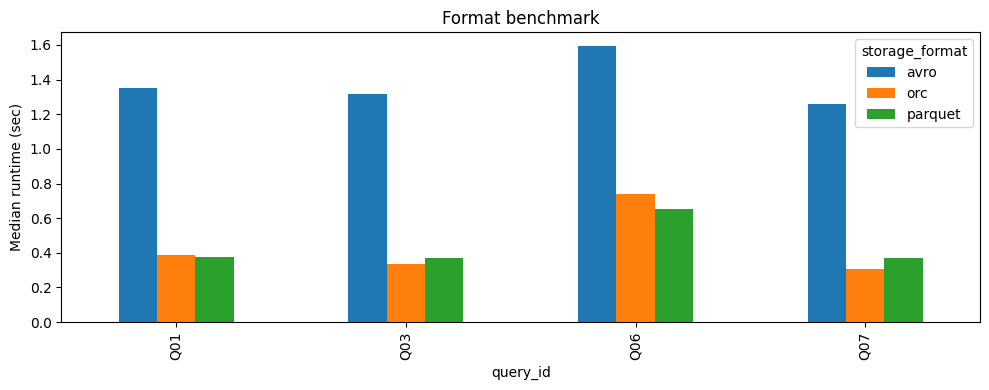

In [4]:
format_frames = []
for fmt in ["parquet", "orc", "avro"]:
    if fmt in dfs and not dfs[fmt].empty:
        table = median_table(dfs[fmt]).copy()
        table["storage_format"] = fmt
        format_frames.append(table)

if format_frames:
    format_pdf = pd.concat(format_frames, ignore_index=True)
    display(format_pdf)
    pivot = format_pdf.pivot(index="query_id", columns="storage_format", values="median_runtime_sec")
    display(pivot)
    pivot.plot(kind="bar", figsize=(10, 4))
    plt.ylabel("Median runtime (sec)")
    plt.title("Format benchmark")
    plt.tight_layout()
    plt.show()
else:
    print("Format benchmark files are missing or empty.")


## 3. Partition comparison

In [5]:
if "partition" in dfs and not dfs["partition"].empty:
    partition_pdf = median_table(dfs["partition"])
    display(partition_pdf)
else:
    print("Partition benchmark file is missing or empty.")


,query_id,query_name,median_runtime_sec
0,Q02,time_filter_partition_pruning,0.258807
1,Q05,daily_zone_flow_summary,0.335371
2,Q06,route_ranking_window,0.628203
3,Q07,origin_destination_volume,0.338389


## 4. Raw vs hash-bucketed layout

,query_id,query_name,median_runtime_sec,layout
0,Q11,bucketed_origin_zone_lookup,0.381864,raw
1,Q12,bucketed_origin_zone_join,0.506112,raw
2,Q11,bucketed_origin_zone_lookup,0.258947,bucketed_origin_zone_hash
3,Q12,bucketed_origin_zone_join,0.404518,bucketed_origin_zone_hash


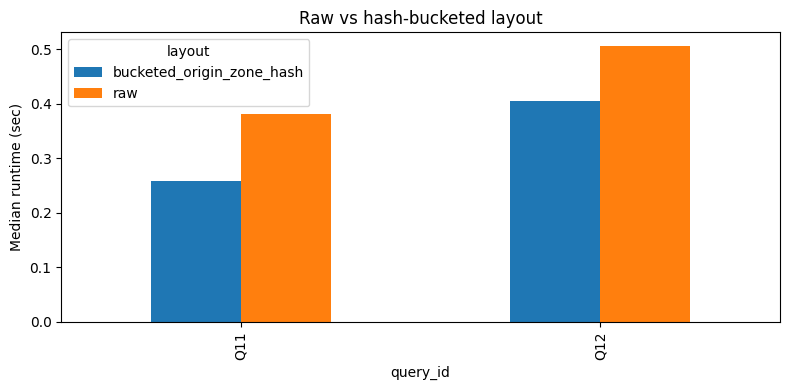

In [6]:
if all(name in dfs and not dfs[name].empty for name in ["bucketing_raw", "bucketing_bucketed"]):
    bucket_raw_pdf = median_table(dfs["bucketing_raw"])
    bucket_raw_pdf["layout"] = "raw"
    bucket_bucketed_pdf = median_table(dfs["bucketing_bucketed"])
    bucket_bucketed_pdf["layout"] = "bucketed_origin_zone_hash"
    bucket_pdf = pd.concat([bucket_raw_pdf, bucket_bucketed_pdf], ignore_index=True)
    display(bucket_pdf)
    bucket_pivot = bucket_pdf.pivot(index="query_id", columns="layout", values="median_runtime_sec")
    bucket_pivot.plot(kind="bar", figsize=(8, 4))
    plt.ylabel("Median runtime (sec)")
    plt.title("Raw vs hash-bucketed layout")
    plt.tight_layout()
    plt.show()
else:
    print("Bucketing benchmark files are missing or empty.")


## 5. Join and skew comparison

,query_id,query_name,median_runtime_sec
0,Q04,origin_zone_skew_aggregation,0.340172
1,Q08,zone_join_baseline,1.374923
2,Q09,zone_broadcast_join,0.522858
3,Q10,salted_zone_join,1.854158


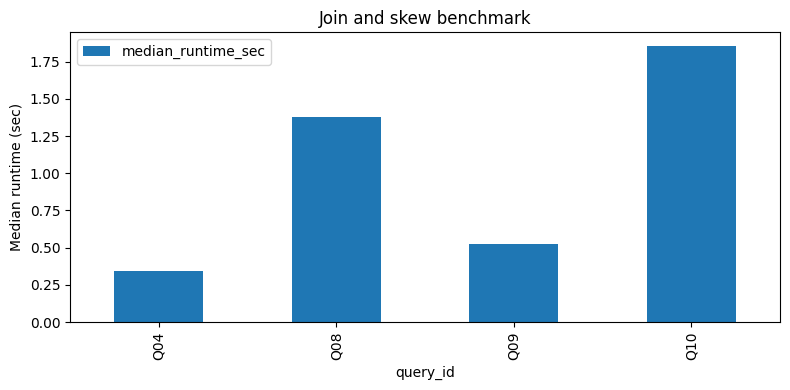

In [7]:
if "join_skew" in dfs and not dfs["join_skew"].empty:
    join_pdf = median_table(dfs["join_skew"])
    display(join_pdf)
    join_pdf.plot(x="query_id", y="median_runtime_sec", kind="bar", figsize=(8, 4))
    plt.ylabel("Median runtime (sec)")
    plt.title("Join and skew benchmark")
    plt.tight_layout()
    plt.show()
else:
    print("Join/skew benchmark file is missing or empty.")


## 6. Talking points for presentation

- ORC va Parquet thuong phu hop hon Avro cho analytic workload.
- Partitioning theo `trip_year`, `trip_month` giup query theo thoi gian dat pruning ro hon.
- Hash-bucketed layout giup query tap trung theo `origin_zone_id` nhanh hon raw.
- Broadcast join voi dimension nho la chien luoc hop ly cho benchmark hien tai.
